#  Credit Card Fraud Detection
**Level 2 - Project 3**

**Objective:** Detect fraud in highly imbalanced credit card data using SMOTE + ML.



In [1]:
!pip install numpy pandas matplotlib seaborn scikit-learn imbalanced-learn xgboost --quiet

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import *
from imblearn.over_sampling import SMOTE
from collections import Counter
import warnings; warnings.filterwarnings('ignore')
print('✅ Libraries imported!')

✅ Libraries imported!


## Load Dataset

In [3]:
from google.colab import files
import io
uploaded = files.upload()
filename = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[filename]))
print(f'Shape: {df.shape}')
print(f'Fraud: {df["Class"].sum()} ({df["Class"].mean()*100:.3f}%)')
print(f'Legitimate: {(df["Class"]==0).sum()}')

Saving creditcard.csv to creditcard.csv
Shape: (284807, 31)
Fraud: 492 (0.173%)
Legitimate: 284315


## EDA

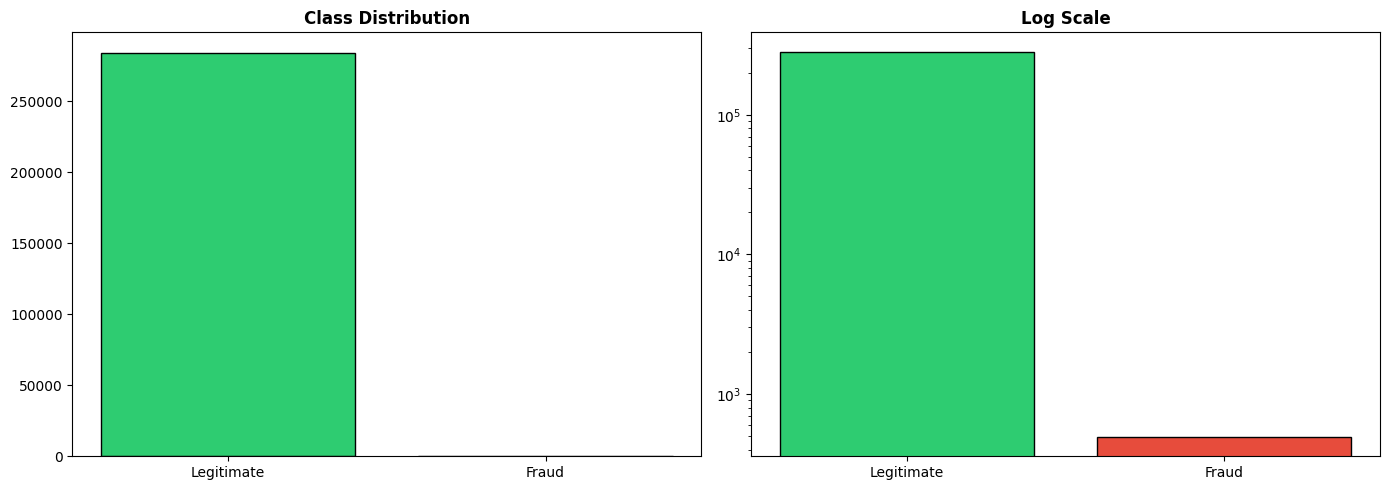

In [4]:
fig,axes=plt.subplots(1,2,figsize=(14,5))
colors=['#2ecc71','#e74c3c']
cd=df['Class'].value_counts()
axes[0].bar(['Legitimate','Fraud'],cd.values,color=colors,edgecolor='black')
axes[0].set_title('Class Distribution',fontweight='bold')
axes[1].bar(['Legitimate','Fraud'],cd.values,color=colors,edgecolor='black')
axes[1].set_yscale('log'); axes[1].set_title('Log Scale',fontweight='bold')
plt.tight_layout(); plt.show()

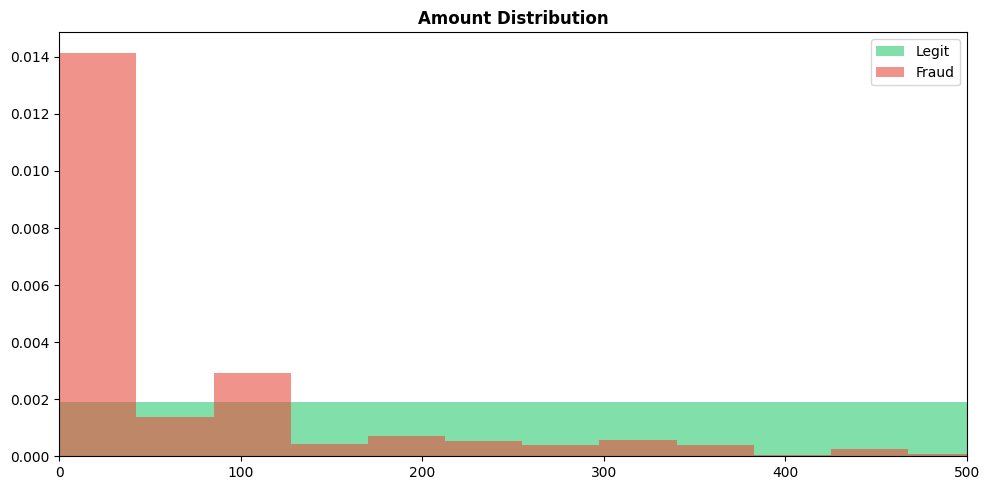

In [5]:
# Amount analysis
fig,ax=plt.subplots(figsize=(10,5))
ax.hist(df[df['Class']==0]['Amount'],bins=50,alpha=0.6,color='#2ecc71',label='Legit',density=True)
ax.hist(df[df['Class']==1]['Amount'],bins=50,alpha=0.6,color='#e74c3c',label='Fraud',density=True)
ax.set_xlim(0,500); ax.set_title('Amount Distribution',fontweight='bold')
ax.legend(); plt.tight_layout(); plt.show()

## Preprocessing

In [6]:
rs=RobustScaler()
df['Amount_s']=rs.fit_transform(df['Amount'].values.reshape(-1,1))
df['Time_s']=rs.fit_transform(df['Time'].values.reshape(-1,1))
df2=df.drop(['Amount','Time'],axis=1)
X=df2.drop('Class',axis=1); y=df2['Class']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

# SMOTE
sm=SMOTE(random_state=42,sampling_strategy=0.5)
X_sm,y_sm=sm.fit_resample(X_train,y_train)
print(f'Before SMOTE: {dict(Counter(y_train))}')
print(f'After SMOTE: {dict(Counter(y_sm))}')

Before SMOTE: {0: 227451, 1: 394}
After SMOTE: {0: 227451, 1: 113725}


## Model Training

In [10]:
models={'Logistic Regression':LogisticRegression(max_iter=1000,random_state=42),
        'Random Forest':RandomForestClassifier(n_estimators=100,random_state=42,n_jobs=-1),
        'XGBoost':XGBClassifier(n_estimators=100,random_state=42,eval_metric='logloss',use_label_encoder=False)}
results={}
for name,model in models.items():
    model.fit(X_sm,y_sm)
    yp=model.predict(X_test); yprob=model.predict_proba(X_test)[:,1]
    results[name]={'Precision':precision_score(y_test,yp),'Recall':recall_score(y_test,yp),
        'F1':f1_score(y_test,yp),'AUC':roc_auc_score(y_test,yprob),'yp':yp,'yprob':yprob}
    print(f'{name}: Recall={results[name]["Recall"]:.4f}, F1={results[name]["F1"]:.4f}')

Logistic Regression: Recall=0.8980, F1=0.1917
Random Forest: Recall=0.8367, F1=0.8542
XGBoost: Recall=0.8673, F1=0.8019


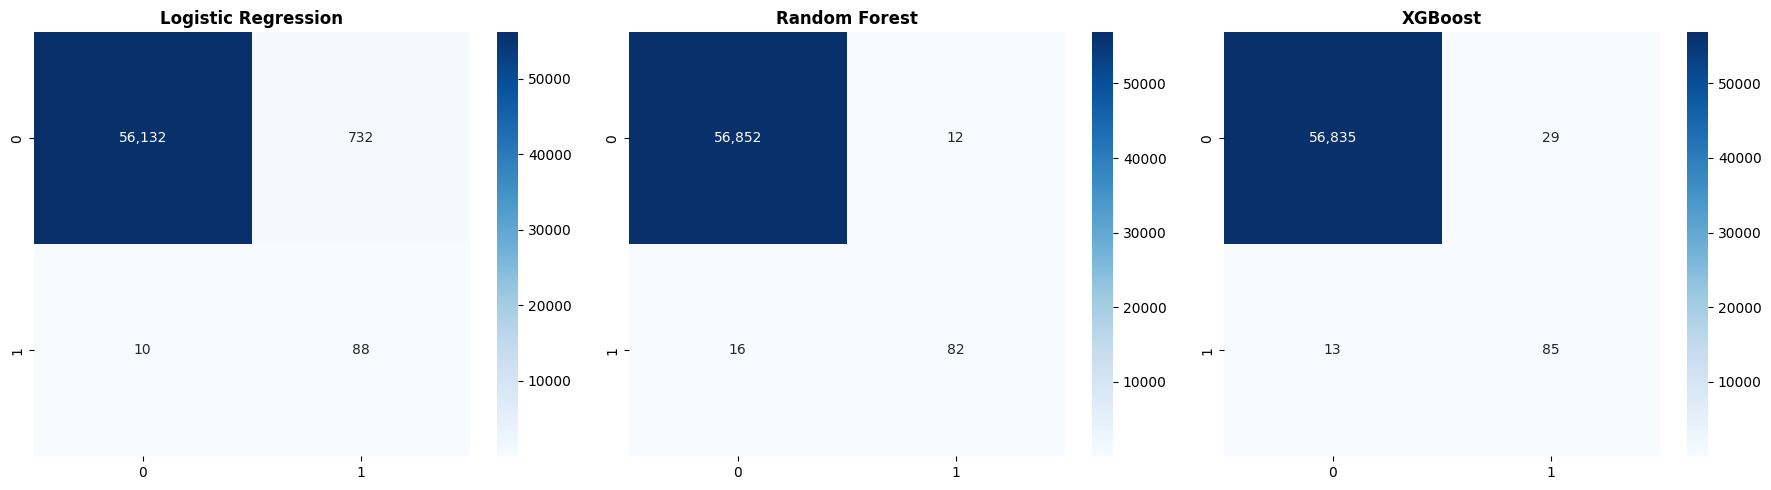

In [11]:
# Confusion matrices
fig,axes=plt.subplots(1,3,figsize=(18,5))
for i,(name,r) in enumerate(results.items()):
    cm=confusion_matrix(y_test,r['yp'])
    sns.heatmap(cm,annot=True,fmt=',d',cmap='Blues',ax=axes[i])
    axes[i].set_title(name,fontweight='bold')
plt.tight_layout(); plt.show()

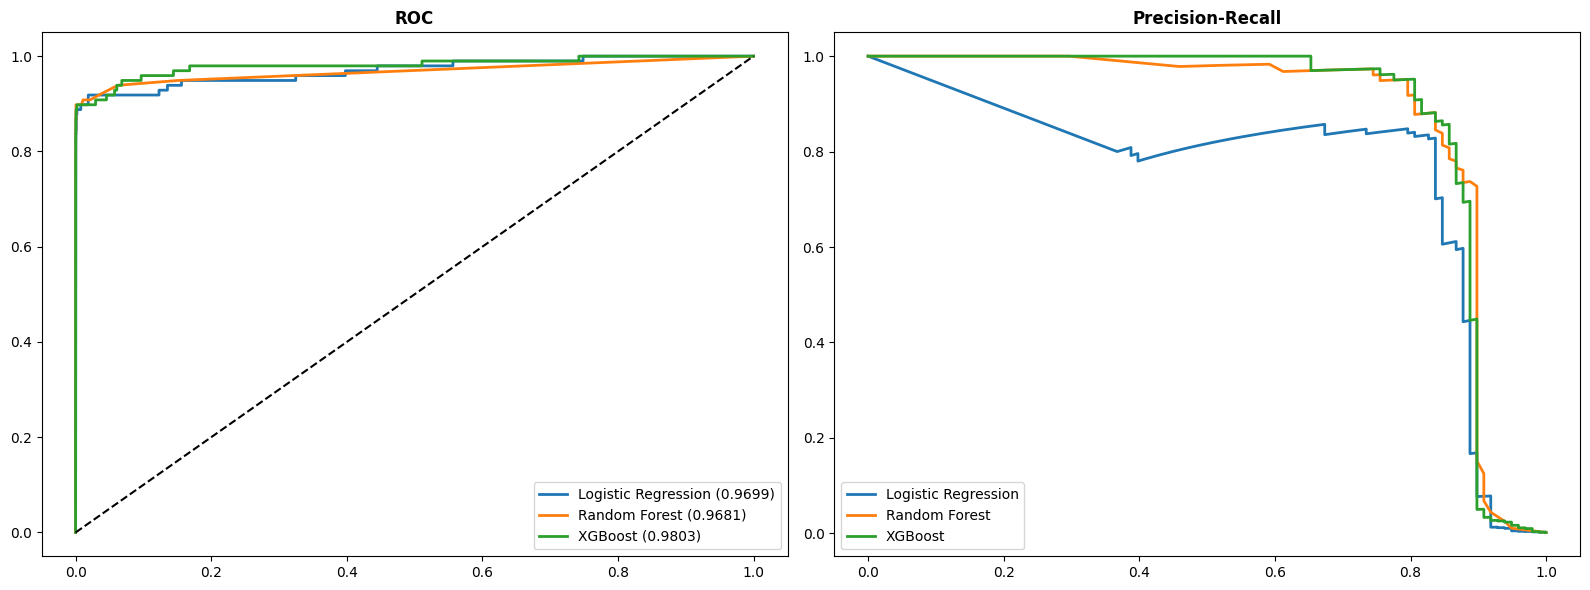

In [12]:
# ROC & PR curves
fig,axes=plt.subplots(1,2,figsize=(16,6))
for name,r in results.items():
    fpr,tpr,_=roc_curve(y_test,r['yprob'])
    axes[0].plot(fpr,tpr,lw=2,label=f"{name} ({r['AUC']:.4f})")
    pr,rc,_=precision_recall_curve(y_test,r['yprob'])
    axes[1].plot(rc,pr,lw=2,label=name)
axes[0].plot([0,1],[0,1],'k--'); axes[0].set_title('ROC',fontweight='bold'); axes[0].legend()
axes[1].set_title('Precision-Recall',fontweight='bold'); axes[1].legend()
plt.tight_layout(); plt.show()

## Summary

In [14]:
comp=pd.DataFrame({n:{k:v for k,v in r.items() if k not in['yp','yprob']} for n,r in results.items()}).T
print(comp)
print(f'\n Best: {comp["F1"].idxmax()}')

                     Precision    Recall        F1       AUC
Logistic Regression   0.107317  0.897959  0.191721  0.969899
Random Forest         0.872340  0.836735  0.854167  0.968129
XGBoost               0.745614  0.867347  0.801887  0.980320

 Best: Random Forest
